In [1]:
import torch
import numpy as np
import pandas as pd
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection, LineCollection

In [2]:
def get_rects_verts_2d(rects):
    return torch.stack(
        [
            rects[:, 0, :2],
            rects[:, 0, :2] + rects[:, 1, :2],
            rects[:, 0, :2] + rects[:, 1, :2] + rects[:, 2, :2],
            rects[:, 0, :2] + rects[:, 2, :2],
        ],
        dim=1,
    )


def get_rects_center_2d(rects):
    return rects[:, 0, :2] + 0.5 * (rects[:, 1, :2] + rects[:, 2, :2])


def rects_edges_2d(rects):
    verts = get_rects_verts_2d(rects)
    edges = torch.stack(
        [
            verts[:, (0, 1)],
            verts[:, (1, 2)],
            verts[:, (2, 3)],
            verts[:, (3, 0)],
        ],
        dim=1,
    )
    return edges


def get_rays(
    pa_arr: torch.Tensor, pb_arr: torch.Tensor, device: torch.device
) -> torch.Tensor:
    """
    Get rays from array of points a and array of points b
    """
    npa = pa_arr.shape[0]
    npb = pb_arr.shape[0]
    return torch.stack(
        (
            pa_arr.view(-1, 1, 2).expand(-1, npb, -1),
            pb_arr.view(1, -1, 2).expand(npa, -1, -1),
        ),
        dim=2,
    )


def abrays_cut_rects_2d(
    pa_arr: torch.Tensor,
    pb_arr: torch.Tensor,
    edges: torch.Tensor,
    device: torch.device,
):
    """
    Cut rays with line segments (edges)
    """

    n_pa = pa_arr.shape[0]
    n_pb = pb_arr.shape[0]
    n_rects = edges.shape[0]
    rays = get_rays(pa_arr, pb_arr, device)
    v1 = rays[:, :, 1] - rays[:, :, 0]
    v2 = edges[:, :, 0] - edges[:, :, 1]
    # try:
    v3 = edges[:, :, 0].view(1, -1, 4, 2).expand(n_pa, -1, -1, -1) - pa_arr.view(
        -1, 1, 1, 2
    ).expand(-1, n_rects, 4, -1)

    # cramer's rule
    v1 = v1.view(n_pa, n_pb, 1, 1, 2).expand(-1, -1, n_rects, 4, -1)
    v2 = v2.view(1, 1, n_rects, 4, 2).expand(n_pa, n_pb, -1, -1, -1)
    v3 = v3.view(n_pa, 1, n_rects, 4, 2).expand(-1, n_pb, -1, -1, -1)
    det = v1[:, :, :, :, 0] * v2[:, :, :, :, 1] - v1[:, :, :, :, 1] * v2[:, :, :, :, 0]
    t = torch.where(
        det != 0,
        (v3[:, :, :, :, 0] * v2[:, :, :, :, 1] - v2[:, :, :, :, 0] * v3[:, :, :, :, 1])
        / det,
        -1,
    )
    s = torch.where(
        det != 0,
        (v1[:, :, :, :, 0] * v3[:, :, :, :, 1] - v1[:, :, :, :, 1] * v3[:, :, :, :, 0])
        / det,
        -1,
    )
    t[t > 1] = float("nan")
    t[t < 0] = float("nan")
    t = torch.where((s <= 1) * (s >= 0), t, float("nan"))
    index = torch.argwhere(~torch.isnan(t))
    return t[index[:, 0], index[:, 1], index[:, 2], index[:, 3]], index


def get_fov_centers_2d(npx_xy, mmppx_xy, device: torch.device):
    gridx, gridy = torch.meshgrid(
        torch.arange(npx_xy[0], device=device),
        torch.arange(npx_xy[1], device=device),
        indexing="ij",
    )
    fov_dims = npx_xy * mmppx_xy
    return (
        torch.stack((gridx, gridy), dim=-1) + torch.tensor([0.5, 0.5])
    ) * mmppx_xy - fov_dims * 0.5


def plot_cuboids(cuboids, ax, alpha=1, fc="r", ec="none"):
    verts = get_rects_verts_2d(cuboids.view(-1, 4, 3))
    patches = []
    for vert in verts:
        polygon = Polygon(vert, closed=True)
        patches.append(polygon)

    p = PatchCollection(patches, fc=fc, ec=ec, alpha=alpha)
    ax.add_collection(p)


def plot_rects(rects, ax, **kwargs):
    verts = get_rects_verts_2d(rects)
    patches = []
    for vert in verts:
        polygon = Polygon(vert, closed=True)
        patches.append(polygon)

    p = PatchCollection(patches, kwargs)
    ax.add_collection(p)


def get_scanner_cuboids(fpath: str):
    with np.load(fpath) as data:
        xtal_cuboids = torch.tensor(data["crystal cuboids"])
        plate_cuboids = torch.tensor(data["plate cuboids"])
    return xtal_cuboids, plate_cuboids


def plot_scanner(xtal_cuboids, plate_cuboids, ax):
    plot_cuboids(xtal_cuboids, ax, alpha=1, fc="orange")
    plot_cuboids(plate_cuboids, ax, fc="darkgray")


def plot_cuboid(id, xtal_cuboids, ax, fc="r", ec="none"):
    plot_cuboids(xtal_cuboids.view(-1, 4, 3)[id], ax, fc=fc, ec=ec, alpha=0.5)

In [3]:
device = torch.device("cpu")
scanner_id = 0
xtal_id = 20
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([32, 32])
fov_dims = fov_npx * fov_mmppx
xtal_cuboids, plate_cuboids = get_scanner_cuboids("./detector_cuboids.npz")

# concatenate plate cubois and other xtal cuboids
other_cuboids = torch.cat(
    [
        plate_cuboids.view(-1, 4, 3),
        xtal_cuboids.view(-1, 4, 3)[:xtal_id],
        xtal_cuboids.view(-1, 4, 3)[xtal_id + 1 :],
    ]
)
# mu tensor for attenuation coefficient
mu_tensor_plate = torch.tensor(3.5).expand(plate_cuboids.view(-1, 4, 3).shape[0])
mu_tensor_xtal = torch.tensor(0.475).expand(xtal_cuboids.view(-1, 4, 3).shape[0])
mu_tensor_other = torch.cat((mu_tensor_plate, mu_tensor_xtal[1:]))

# get the points a and b for the rays
pa_arr = get_fov_centers_2d(fov_npx, fov_mmppx, device)
pb_arr = get_rects_center_2d(xtal_cuboids.view(-1, 4, 3)[xtal_id].view(1,4,3))
n_pa = pa_arr.view(-1, 2).shape[0]
n_pb = pb_arr.view(-1, 2).shape[0]

# get the rays from the points a and b
rays = get_rays(pa_arr.view(-1, 2), pb_arr.view(-1, 2), device)

print(n_pa, n_pb, rays.shape)


16 1 torch.Size([16, 1, 2, 2])


In [4]:
## Ray tracing on the crystal itself
edges_self = rects_edges_2d(
    xtal_cuboids.view(-1, 4, 3)[xtal_id, :3, :2].view(1, 3, 2)
)

### Ray tracing
t_self, t_idx_self = abrays_cut_rects_2d(
    pa_arr.view(-1, 2), pb_arr.view(1, 2), edges_self, device
)

rays_cut_self = rays[t_idx_self[:, 0], t_idx_self[:, 1]]
cuts_self = rays_cut_self[:, 0] + t_self.view(-1, 1) * (
    rays_cut_self[:, 1] - rays_cut_self[:, 0]
)

## Ray tracing on the plates and other crystals

edges_other = rects_edges_2d(other_cuboids[:, :3, :2])
n_other_cuboids = other_cuboids.shape[0]

### Ray tracing
t_other, t_idx_other = abrays_cut_rects_2d(
    pa_arr.view(-1, 2), pb_arr.view(1, 2), edges_other, device
)

rays_cut_other = rays[t_idx_other[:, 0], t_idx_other[:, 1]]

cuts_other = rays_cut_other[:, 0] + t_other.view(-1, 1) * (
    rays_cut_other[:, 1] - rays_cut_other[:, 0]
)

### Get the line segments length
dl_len_self = torch.linalg.norm(
    rays_cut_self[:, 1] - rays_cut_self[:, 0], dim=1
) * (1 - t_self)
dl_len_other = torch.abs(t_other[1::2] - t_other[::2]) * torch.linalg.norm(
    rays_cut_other[::2, 1] - rays_cut_other[::2, 0], dim=1
)

dlmu_attenu = dl_len_other * mu_tensor_other[t_idx_other[::2][:, 2]]
dlmu_absorb = dl_len_self * mu_tensor_xtal[xtal_id]

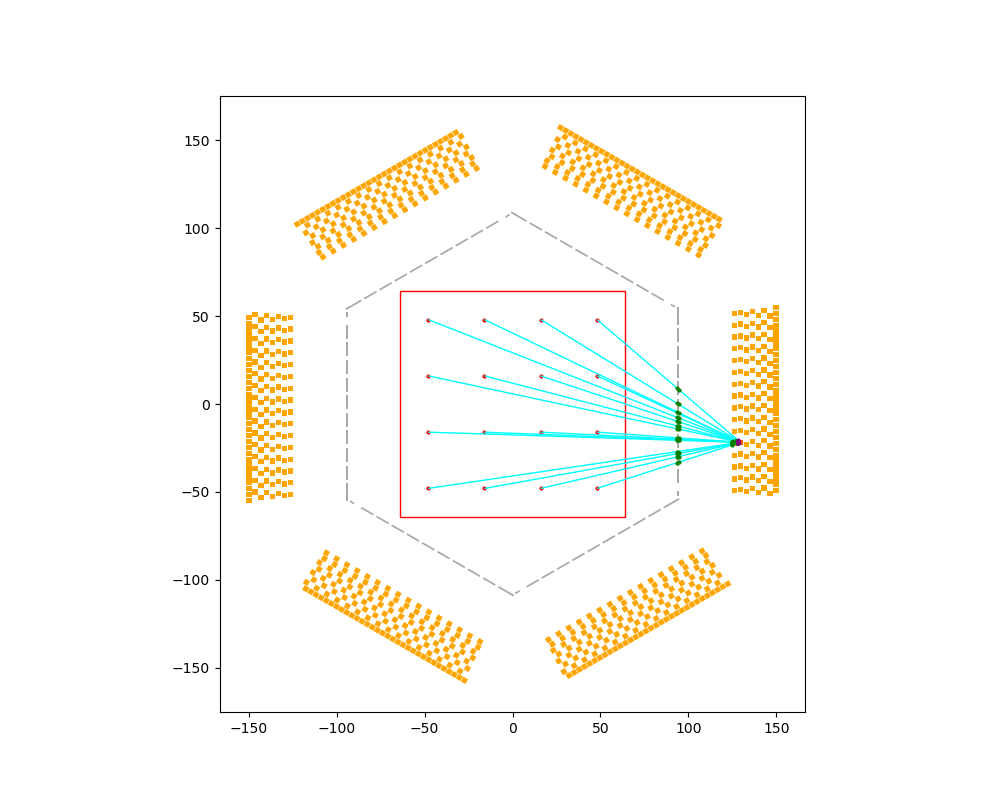

In [5]:
## Plotting

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
ax.set_aspect("equal")

plot_scanner(xtal_cuboids, plate_cuboids, ax)
plot_cuboid(xtal_id, xtal_cuboids, ax)

# ax.pcolormesh(ppdf, ,edgecolors="black", linewidth=0.5)
ax.add_patch(
    plt.Rectangle(
        -fov_dims * 0.5,
        fov_npx[0] * fov_mmppx[0],
        fov_npx[1] * fov_mmppx[1],
        fill=False,
        edgecolor="red",
    )
)


# ax.plot(pb_arr[:,0], pb_arr[:,1], "o", ms=1, color="b")
ax.plot(pa_arr.view(-1, 2)[:, 0], pa_arr.view(-1, 2)[:, 1], "o", ms=2, c="r")
lines = rays.view(-1, 2, 2).numpy()
lines_segs = LineCollection(lines, colors="cyan", linewidths=1,ls='-')
ax.add_collection(lines_segs)
ax.plot(cuts_other[:, 0], cuts_other[:, 1], "o", ms=2, c="green")
ax.plot(cuts_self[:, 0], cuts_self[:, 1], "o", ms=2, c="purple")
plt.show()

shape of rays torch.Size([1, 3, 2, 2])
shape of rects torch.Size([3, 3, 2])
shape of angular_term torch.Size([1, 3])
angular_term tensor([[0.0780, 0.2500, 0.0265]])


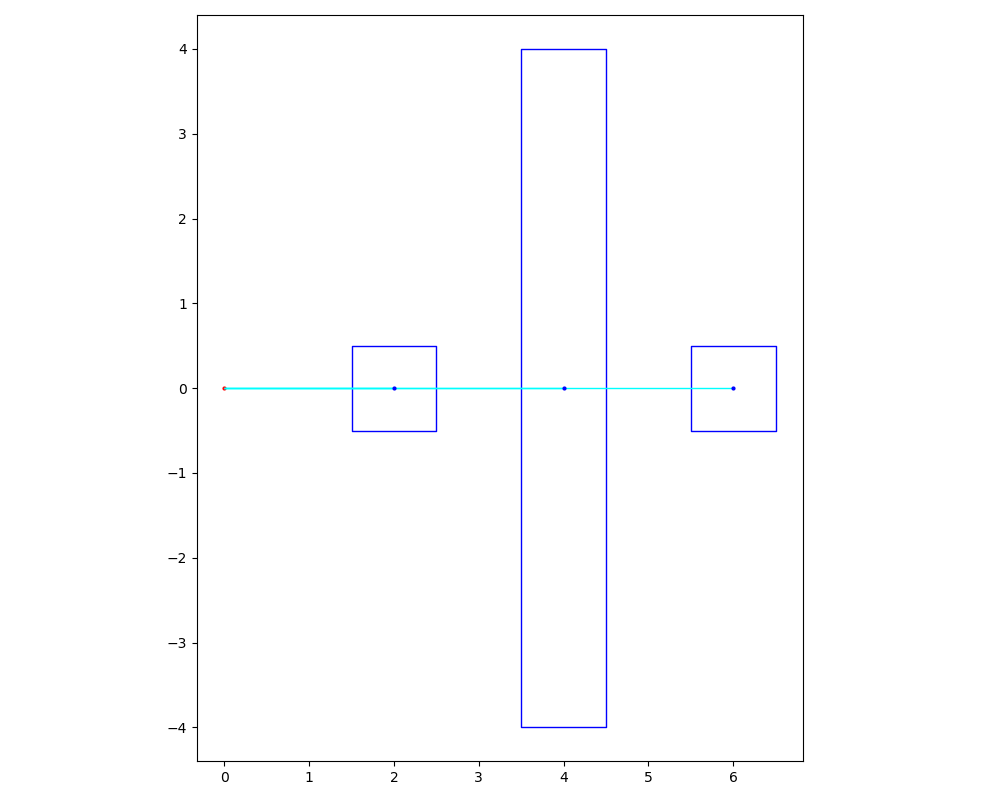

In [6]:
## Test the angular term calculation
try:
    plt.close()
except Exception as e:
    pass


def plot_rects(rects, ax, **kwargs):
    verts = get_rects_verts_2d(rects)
    p = PatchCollection([Polygon(vert, closed=True) for vert in verts], **kwargs)
    ax.add_collection(p)


def get_angular_term(rays, rects):
    pi = 3.14159265358979323846
    # The 2nd dimension of the rays must match the first dimension of the rects
    rects_vecs = (
        torch.stack([-rects[:, 1:, 1], rects[:, 1:, 0]], dim=2)
        .unsqueeze(0)
        .expand(rays.shape[0], -1, -1, -1)
    )
    rays_vecs = rays[:, :, 1] - rays[:, :, 0]
    rays_len = torch.linalg.norm(rays_vecs, dim=2)
    proj = (
        torch.abs(
            (rects_vecs * rays_vecs.unsqueeze(2).expand(-1, -1, 2, -1)).sum(dim=3)
        ).sum(dim=2)
        / rays_len
    )
    ratio = torch.atan2(0.5 * proj, rays_len) / pi
    return ratio
    # rays_vecs_norm = torch.linalg.norm(rays_vecs, dim=2)
    # rects_vects_norm = torch.linalg.norm(rects_vecs, dim=2)
    # # dot_p_normalized = dot_p / torch.linalg.norm(rays_vecs, dim=2)
    # # print(dot_p_sum.shape)
    # result = dot_p / (rays_vecs_norm * rects_vects_norm)
    # print('result',result)
    # return torch.sum(dot_p / (rays_vecs_norm * rects_vects_norm), dim=1).view(rays.shape[:2])


pa_arr = torch.tensor([[0, 0]], dtype=torch.float32)
rects = torch.tensor(
    [
        [[1.5, -0.5], [1, 0], [0, 1]],
        [[3.5, -4], [1, 0], [0, 8]],
        [[5.5, -0.5], [1, 0], [0, 1]],
    ],
    dtype=torch.float32,
)
pb_arr = get_rects_center_2d(rects)
rays = get_rays(pa_arr, pb_arr, device)
print("shape of rays", rays.shape)
print("shape of rects", rects.shape)
angular_term = get_angular_term(rays, rects)
rays_len = torch.linalg.norm(rays[:, :, 1] - rays[:, :, 0], dim=2)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
ax.plot(pa_arr[:, 0], pa_arr[:, 1], "o", ms=2, c="r")
lines_segs = LineCollection(rays.view(-1, 2, 2), colors="cyan", linewidths=1, ls="-")
ax.add_collection(lines_segs)
plot_rects(rects, ax, fc="none", ec="b")
ax.plot(pb_arr[:, 0], pb_arr[:, 1], "o", ms=2, c="b")
# annotation_text = f"""
# {'Angular term:':16s}{angular_term[0,0]:2.2f}
# {'rays length :':16s}{rays_len[0,0]:2.2f}
# """

# ax.annotate(
#     annotation_text,
#     xy=(0.5, 0.5),
#     xycoords="axes fraction",
#     xytext=(0.02, 0.96),
#     textcoords="axes fraction",
#     fontsize=12,
#     fontfamily="monospace",
#     ha="left",
#     va="top",
#     # bbox=dict(boxstyle="round,pad=0.1", fc="cyan", ec="b", lw=1, alpha=0.5),
# )
fig.tight_layout()
print("shape of angular_term", angular_term.shape)
print("angular_term", angular_term)

In [7]:
rects_vecs = torch.stack([-rects[:, 1:, 1], rects[:, 1:, 0]],dim=2)
print(rects_vecs)

tensor([[[-0.,  1.],
         [-1.,  0.]],

        [[-0.,  1.],
         [-8.,  0.]],

        [[-0.,  1.],
         [-1.,  0.]]])


### Focus on a single crystal but with subdivisions

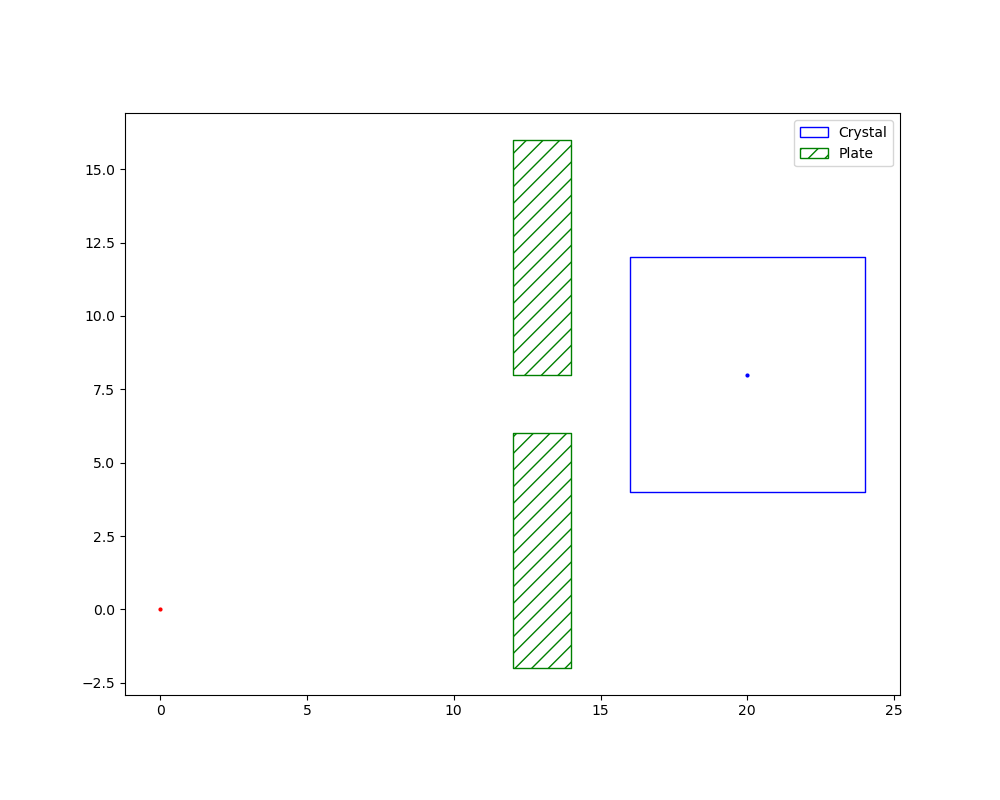

In [8]:
plt.close()
pa_arr = torch.tensor([[0, 0]], dtype=torch.float32)
rects = torch.tensor(
    [
        [[16, 4], [8, 0], [0, 8]],
    ],
    dtype=torch.float32,
)

rects_plate = torch.tensor(
    [
        [[12, 8], [2, 0], [0, 8]],
        [[12, -2], [2, 0], [0, 8]],
    ],
    dtype=torch.float32,
)


rects_centers = get_rects_center_2d(rects)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
ax.plot(pa_arr[:, 0], pa_arr[:, 1], "o", ms=2, c="r")
# lines_segs = LineCollection(rays.view(-1, 2, 2), colors="cyan", linewidths=1, ls="-")
# ax.add_collection(lines_segs)
legend_handles = []
patches_styles = [
    {"fc": "none", "ec": "b", "label": "Crystal"},
    {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
]
plot_rects(rects, ax, **patches_styles[0])
plot_rects(rects_plate, ax, **patches_styles[1])
for pstyle in patches_styles:
    patch = mpatches.Patch(**pstyle)
    legend_handles.append(patch)
ax.set_aspect("equal")
ax.plot(rects_centers[:, 0], rects_centers[:, 1], "o", ms=2, c="b")
# Create legend handles

# Add legend
ax.legend(handles=legend_handles)



#### Subdivide the crystal

In [9]:
def get_rect_subdivs(rects, nsubs):
    nsubs_total = nsubs.prod()
    x, y = torch.meshgrid(
        torch.linspace(0, 1, nsubs[0] + 1)[:-1],
        torch.linspace(0, 1, nsubs[1] + 1)[:-1],
        indexing="ij",
    )
    rects_exp = rects.expand(nsubs_total, -1, -1)
    return torch.cat(
        [
            (
                x.flatten().view(-1, 1).expand(-1, 2) * rects_exp[:, 1]
                + y.flatten().view(-1, 1).expand(-1, 2) * rects_exp[:, 2]
                + rects[0][0]
            ).view(-1, 1, 2),
            rects_exp[:, 1:] / nsubs.view(1, 1, 2).expand(nsubs_total, 2, -1),
        ],
        dim=1,
    )

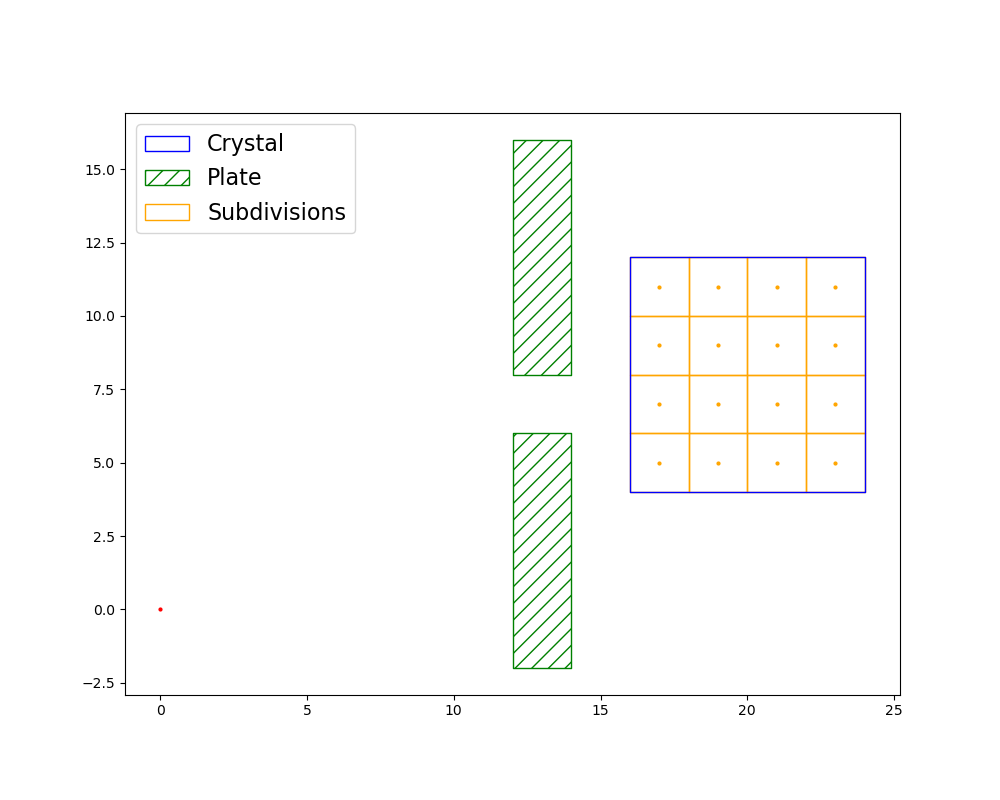

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
ax.set_aspect("equal")
ax.plot(pa_arr[:, 0], pa_arr[:, 1], "o", ms=2, c="r")
# lines_segs = LineCollection(rays.view(-1, 2, 2), colors="cyan", linewidths=1, ls="-")
# ax.add_collection(lines_segs)
legend_handles = []
patches_styles = [
    {"fc": "none", "ec": "b", "label": "Crystal"},
    {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
    {"fc": "none", "ec": "orange", "label": "Subdivisions"},
]
xtal_nsubs = torch.tensor([4, 4])
rects_subs = get_rect_subdivs(rects, xtal_nsubs)
plot_rects(rects_plate, ax, **patches_styles[1])
plot_rects(rects_subs, ax, **patches_styles[2])
plot_rects(rects, ax, **patches_styles[0])
pb_arr = get_rects_center_2d(rects_subs)

for pstyle in patches_styles:
    patch = mpatches.Patch(**pstyle)
    legend_handles.append(patch)
ax.set_aspect("equal")

ax.plot(pb_arr[:, 0], pb_arr[:, 1], "o", ms=2, c="orange")
# ax.plot(
# Create legend handles

# Add legend
ax.legend(handles=legend_handles,prop={'size': 16},loc='upper left')

In [11]:
def get_rays_cut_subdivs_self_2d(
    rays: torch.Tensor,
    edges: torch.Tensor,
):
    """
    Cut rays with line segments (edges) of subdiv
    """
    # expand v1 shape (n_pa, n_pb, 2) to (n_pa, n_pb, 4, 2)
    v1 = (rays[:, :, 1] - rays[:, :, 0]).unsqueeze(2).expand(-1, -1, 4, -1)

    # expand v2 shape (n_pb, 4, 2) to (n_pa, n_pb, 4, 2)
    v2 = (edges[:, :, 0] - edges[:, :, 1]).unsqueeze(0).expand_as(v1)

    # v3 should be v3 = (edges_start_vert - rays_start_vert)
    v3 = edges[:, :, 0].unsqueeze(0).expand_as(v1) - rays[:, :, 0].unsqueeze(
        2
    ).expand_as(v1)

    # shape of v1, v2, v3 unified to:
    # (n_pa, n_pb, 4, 2)

    # cramer's rule
    det = v1[:, :, :, 0] * v2[:, :, :, 1] - v1[:, :, :, 1] * v2[:, :, :, 0]
    t = torch.where(
        det != 0,
        (v3[:, :, :, 0] * v2[:, :, :, 1] - v2[:, :, :, 0] * v3[:, :, :, 1]) / det,
        float("nan"),
    )
    s = torch.where(
        det != 0,
        (v1[:, :, :, 0] * v3[:, :, :, 1] - v1[:, :, :, 1] * v3[:, :, :, 0]) / det,
        -1,
    )
    t = torch.where((s <= 1) * (s >= 0) * (t < 1) * (t > 0), t, float("nan"))
    return t[~torch.isnan(t)].view(v1.shape[:2])


# define the subdivisions of the crystal
rect = torch.tensor(
    [
        [[16, 4], [8, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([3, 3])
rect_subs = get_rect_subdivs(rect, xtal_nsubs)

# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([2, 2])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_tensor= get_fov_centers_2d(fov_npx, fov_mmppx, device)
pb_tensor = get_rects_center_2d(rect_subs)
edges_subdivs = rects_edges_2d(rect_subs)
print(edges_subdivs.shape)
rays = get_rays(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2), device)
ts_self = get_rays_cut_subdivs_self_2d(rays, edges_subdivs)
print(ts_self.shape)
# print(ts_self[~torch.isnan(ts_self)].

torch.Size([9, 4, 2, 2])
torch.Size([16, 9])


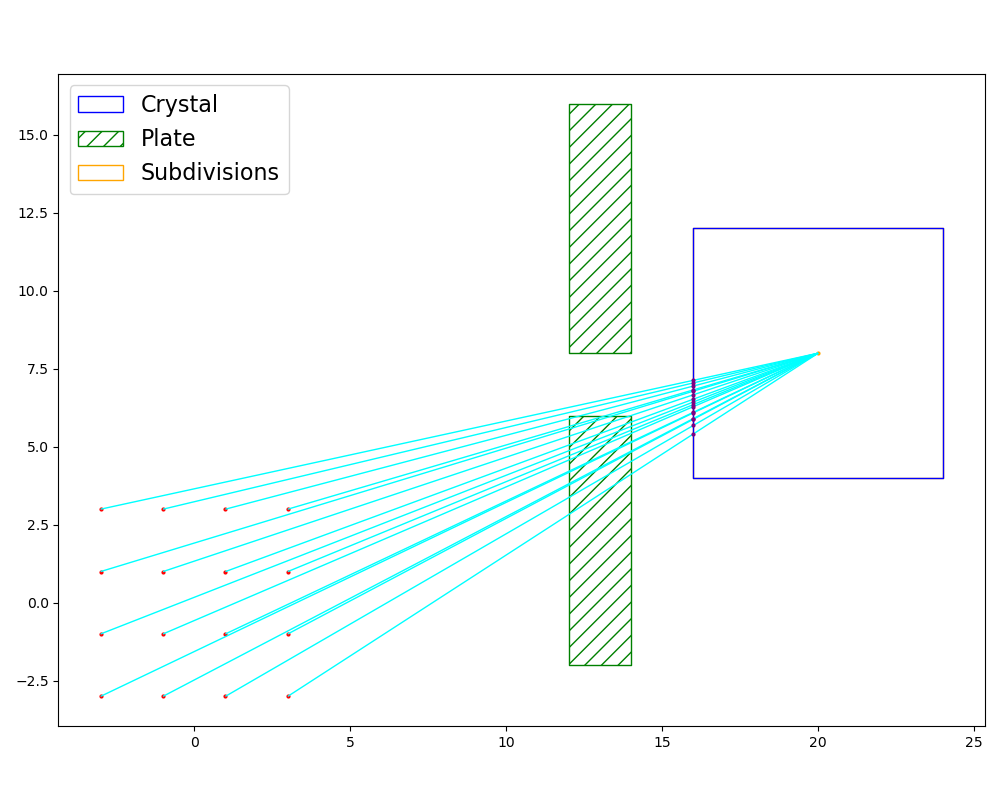

In [12]:
rect = torch.tensor(
    [
        [[16, 4], [8, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([1, 1])
rect_subs = get_rect_subdivs(rect, xtal_nsubs)
edges_subdivs = rects_edges_2d(rect_subs)

# get points B
pb_tensor = get_rects_center_2d(rect_subs)

# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([2, 2])
fov_dims = fov_npx * fov_mmppx

# get the points A
pa_tensor= get_fov_centers_2d(fov_npx, fov_mmppx, device)


rays = get_rays(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2), device)
ts_self = get_rays_cut_subdivs_self_2d(rays, edges_subdivs)

# calculate the coordinates of the cuts
cuts_subdivs = rays[:, :, 0] + ts_self.unsqueeze(-1).expand(-1, -1, 2) * (
    rays[:, :, 1] - rays[:, :, 0]
)

if fig:
    plt.close(fig)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

legend_handles = []
patches_styles = [
    {"fc": "none", "ec": "b", "label": "Crystal"},
    {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
    {"fc": "none", "ec": "orange", "label": "Subdivisions"},
]
plot_rects(rects_plate, ax, **patches_styles[1])
plot_rects(rect_subs, ax, **patches_styles[2])
plot_rects(rects, ax, **patches_styles[0])

for pstyle in patches_styles:
    patch = mpatches.Patch(**pstyle)
    legend_handles.append(patch)
ax.set_aspect("equal")
pa_arr = pa_tensor.view(-1, 2)
pb_arr = pb_tensor.view(-1, 2)

# plot the points a and b
ax.plot(pa_arr[:, 0], pa_arr[:, 1], "o", ms=2, c="r")
ax.plot(pb_arr[:, 0], pb_arr[:, 1], "o", ms=2, c="orange")



#Plot the rays
lines_segs = LineCollection(rays.view(-1, 2, 2), colors="cyan", linewidths=1, ls="-")
ax.add_collection(lines_segs)

# plot the cuts
ax.plot(cuts_subdivs[:, :, 0].flatten(), cuts_subdivs[:, :, 1].flatten(), "o", ms=2, c="purple")

# Create legend handles

# Add legend
ax.legend(handles=legend_handles,prop={'size': 16},loc='upper left')
plt.tight_layout()

torch.Size([9, 4, 2, 2])
torch.Size([16, 9])


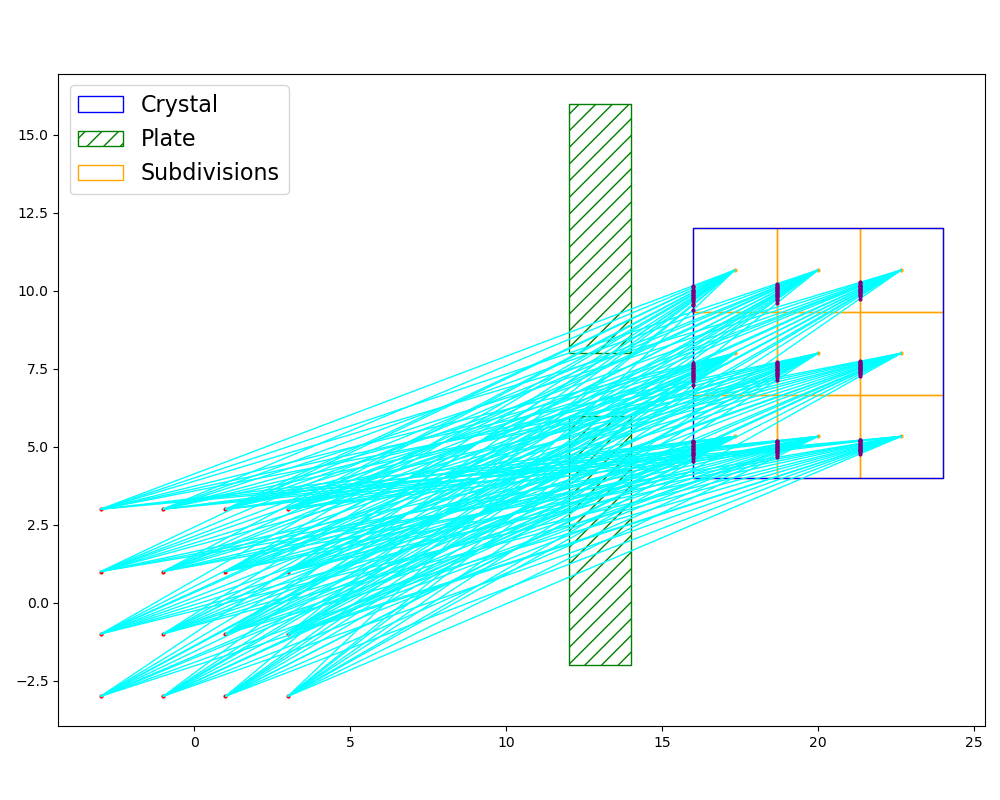

In [13]:
rect = torch.tensor(
    [
        [[16, 4], [8, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([3, 3])
rect_subs = get_rect_subdivs(rect, xtal_nsubs)

# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([2, 2])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_tensor= get_fov_centers_2d(fov_npx, fov_mmppx, device)
pb_tensor = get_rects_center_2d(rect_subs)
edges_subdivs = rects_edges_2d(rect_subs)
print(edges_subdivs.shape)
rays = get_rays(pa_tensor.view(-1, 2), pb_tensor.view(-1, 2), device)
ts_self = get_rays_cut_subdivs_self_2d(rays, edges_subdivs)
print(ts_self.shape)


# calculate the coordinates of the cuts
cuts_subdivs = rays[:, :, 0] + ts_self.unsqueeze(-1).expand(-1, -1, 2) * (
    rays[:, :, 1] - rays[:, :, 0]
)

if fig:
    plt.close(fig)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

legend_handles = []
patches_styles = [
    {"fc": "none", "ec": "b", "label": "Crystal"},
    {"fc": "none", "ec": "green", "hatch": "//", "label": "Plate"},
    {"fc": "none", "ec": "orange", "label": "Subdivisions"},
]
plot_rects(rects_plate, ax, **patches_styles[1])
plot_rects(rect_subs, ax, **patches_styles[2])
plot_rects(rects, ax, **patches_styles[0])

for pstyle in patches_styles:
    patch = mpatches.Patch(**pstyle)
    legend_handles.append(patch)
ax.set_aspect("equal")
pa_arr = pa_tensor.view(-1, 2)
pb_arr = pb_tensor.view(-1, 2)

# plot the points a and b
ax.plot(pa_arr[:, 0], pa_arr[:, 1], "o", ms=2, c="r")
ax.plot(pb_arr[:, 0], pb_arr[:, 1], "o", ms=2, c="orange")



#Plot the rays
lines_segs = LineCollection(rays.view(-1, 2, 2), colors="cyan", linewidths=1, ls="-")
ax.add_collection(lines_segs)

# plot the cuts
ax.plot(cuts_subdivs[:, :, 0].flatten(), cuts_subdivs[:, :, 1].flatten(), "o", ms=2, c="purple")

# Create legend handles

# Add legend
ax.legend(handles=legend_handles,prop={'size': 16},loc='upper left')
plt.tight_layout()

In [14]:

# define the subdivisions of the crystal
rect = torch.tensor(
    [
        [[16, 4], [8, 0], [0, 8]],
    ],
    dtype=torch.float32,
)
xtal_nsubs = torch.tensor([4, 4])
rect_subs = get_rect_subdivs(rect, xtal_nsubs)

# define the field of view (FOV)
fov_npx = torch.tensor([4, 4])
fov_mmppx = torch.tensor([32, 32])
fov_dims = fov_npx * fov_mmppx

# get the points a and b for the rays
pa_arr = get_fov_centers_2d(fov_npx, fov_mmppx, device)
pb_arr = get_rects_center_2d(rect_subs)
n_pa = pa_arr.view(-1, 2).shape[0]
n_pb = pb_arr.view(-1, 2).shape[0]
rays = get_rays(pa_arr.view(-1, 2), pb_arr.view(-1, 2), device)

# mu tensor for attenuation coefficient
mu_tensor_plate = torch.tensor(3.5).expand(rects_plate.shape[0])
mu_tensor_xtal = torch.tensor(0.475).expand(rect_subs.shape[0])
mu_tensor_other = torch.cat((mu_tensor_plate, mu_tensor_xtal[1:]))
print("shape of mu_tensor_other", mu_tensor_other.shape)

shape of mu_tensor_other torch.Size([17])


In [15]:

## Ray tracing on the crystal itself
edges_self = rects_edges_2d(
    xtal_cuboids.view(-1, 4, 3)[xtal_id, :3, :2].view(1, 3, 2)
)

### Ray tracing
t_self, t_idx_self = abrays_cut_rects_2d(
    pa_arr.view(-1, 2), pb_arr.view(-1, 2), edges_self, device
)

rays_cut_self = rays[t_idx_self[:, 0], t_idx_self[:, 1]]
cuts_self = rays_cut_self[:, 0] + t_self.view(-1, 1) * (
    rays_cut_self[:, 1] - rays_cut_self[:, 0]
)

## Ray tracing on the plates and other crystals

edges_other = rects_edges_2d(other_cuboids[:, :3, :2])
n_other_cuboids = other_cuboids.shape[0]

### Ray tracing
t_other, t_idx_other = abrays_cut_rects_2d(
    pa_arr.view(-1, 2), pb_arr.view(-1, 2), edges_other, device
)

rays_cut_other = rays[t_idx_other[:, 0], t_idx_other[:, 1]]

cuts_other = rays_cut_other[:, 0] + t_other.view(-1, 1) * (
    rays_cut_other[:, 1] - rays_cut_other[:, 0]
)

### Get the line segments length
dl_len_self = torch.linalg.norm(
    rays_cut_self[:, 1] - rays_cut_self[:, 0], dim=1
) * (1 - t_self)
dl_len_other = torch.abs(t_other[1::2] - t_other[::2]) * torch.linalg.norm(
    rays_cut_other[::2, 1] - rays_cut_other[::2, 0], dim=1
)

dlmu_attenu = dl_len_other * mu_tensor_other[t_idx_other[::2][:, 2]]
dlmu_absorb = dl_len_self * mu_tensor_xtal[xtal_id]

IndexError: index 20 is out of bounds for dimension 0 with size 16